# Experiment 2 — Encoder–Decoder RNN with Attention for Translation

## Aim
To implement English-to-French translation using an explicit GRU encoder, Bahdanau attention, and autoregressive GRU decoder.

## Objectives

1. Build source and target vocabularies from a public parallel corpus.
2. Implement attention scores, weights, and context vectors directly in PyTorch.
3. Train with teacher forcing and decode greedily at inference time.
4. evaluate loss, BLEU, translations, and an attention heatmap.

## 1–4. Required libraries and configurable setup

In [1]:
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu

CONFIG = {
    "train_samples": 4000, "val_samples": 500, "test_samples": 500,
    "batch_size": 64, "learning_rate": 2e-3, "epochs": 10,
    "embedding_dim": 128, "hidden_dim": 192, "max_sequence_length": 22,
    "min_frequency": 2, "teacher_forcing_ratio": 0.7,
}
CONFIG

Using device: cuda


{'train_samples': 4000,
 'val_samples': 500,
 'test_samples': 500,
 'batch_size': 64,
 'learning_rate': 0.002,
 'epochs': 10,
 'embedding_dim': 128,
 'hidden_dim': 192,
 'max_sequence_length': 22,
 'min_frequency': 2,
 'teacher_forcing_ratio': 0.7}

## Dataset

```text
Dataset: OPUS Books English–French parallel corpus
Dataset source: Hugging Face Datasets — Helsinki-NLP/opus_books, configuration en-fr
Task: English-to-French machine translation
Number of samples: 127,085 aligned sentence pairs in the available corpus
Training samples: CONFIG["train_samples"] after a fixed-seed shuffle
Validation samples: CONFIG["val_samples"] from the same shuffled corpus
Test samples: CONFIG["test_samples"] from the same shuffled corpus
Input format: English sentence (string)
Output format: French sentence (string)
```

The corpus has one official split, so this notebook creates disjoint train/validation/test subsets after a deterministic shuffle. It retains sentence pairs that fit the configured sequence length before taking the subsets; this reduces destructive truncation and makes the small-data lab task learnable. Both languages are lower-cased, regex-tokenized, wrapped with `<bos>`/`<eos>`, numericalized with training-only vocabularies, and padded per batch.

In [2]:
raw = load_dataset("Helsinki-NLP/opus_books", "en-fr", split="train").shuffle(seed=SEED)
total_needed = CONFIG["train_samples"] + CONFIG["val_samples"] + CONFIG["test_samples"]
if total_needed > len(raw):
    raise ValueError("Requested subset exceeds the OPUS Books corpus.")
pairs = []
for row in raw:
    source, target = row["translation"]["en"], row["translation"]["fr"]
    # A conservative whitespace check leaves room for BOS/EOS and punctuation tokens.
    limit = CONFIG["max_sequence_length"] - 4
    if 2 <= len(source.split()) <= limit and 2 <= len(target.split()) <= limit:
        pairs.append((source, target))
    if len(pairs) == total_needed:
        break
if len(pairs) < total_needed:
    raise RuntimeError("Not enough sentence pairs passed the configured length filter.")
n_train, n_val = CONFIG["train_samples"], CONFIG["val_samples"]
train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

display(pd.DataFrame({"split": ["train", "validation", "test"],
                      "samples_used": list(map(len, [train_pairs, val_pairs, test_pairs]))}))
display(pd.DataFrame(train_pairs[:3], columns=["English", "French"]))

,split,samples_used
0,train,4000
1,validation,500
2,test,500


,English,French
0,"""Not if it were my own brother!"" cried d’Artag...","«Non, fût-ce mon frère!» s'écria d'Artagnan co..."
1,"""Mr. Conseil put one over on me!""",Monsieur Conseil qui me fait poser !
2,"""It is impossible a gentleman could have writt...","«Mon Dieu! dit-elle, saurait-il...» Et elle s'..."


In [3]:
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÿ']+|[.!?,;:]")

def tokenize(text):
    """Lower-case word/punctuation tokenizer requiring no external model."""
    return TOKEN_PATTERN.findall(text.lower())

class Vocabulary:
    def __init__(self, texts, min_freq=2, specials=("<pad>", "<unk>", "<bos>", "<eos>")):
        counts = Counter(token for text in texts for token in tokenize(text))
        self.itos = list(specials) + sorted(w for w, n in counts.items() if n >= min_freq and w not in specials)
        self.stoi = {word: index for index, word in enumerate(self.itos)}
        self.pad_idx = self.stoi["<pad>"]
        self.unk_idx = self.stoi["<unk>"]
        self.bos_idx = self.stoi["<bos>"]
        self.eos_idx = self.stoi["<eos>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, max_length, add_boundaries=True):
        tokens = tokenize(text)
        if add_boundaries:
            tokens = ["<bos>"] + tokens[: max_length - 2] + ["<eos>"]
        else:
            tokens = tokens[:max_length]
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def decode(self, ids):
        ignored = {self.pad_idx, self.bos_idx, self.eos_idx}
        return " ".join(self.itos[i] for i in ids if i not in ignored)

src_vocab = Vocabulary((src for src, _ in train_pairs), min_freq=CONFIG["min_frequency"])
tgt_vocab = Vocabulary((tgt for _, tgt in train_pairs), min_freq=CONFIG["min_frequency"])
print(f"English vocabulary: {len(src_vocab):,}; French vocabulary: {len(tgt_vocab):,}")

class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs): self.pairs = sentence_pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, index):
        src, tgt = self.pairs[index]
        return (torch.tensor(src_vocab.encode(src, CONFIG["max_sequence_length"])),
                torch.tensor(tgt_vocab.encode(tgt, CONFIG["max_sequence_length"])))

def collate_translation(batch):
    src, tgt = zip(*batch)
    return (nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=src_vocab.pad_idx),
            nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=tgt_vocab.pad_idx))

loader_kwargs = dict(batch_size=CONFIG["batch_size"], collate_fn=collate_translation)
train_loader = DataLoader(TranslationDataset(train_pairs), shuffle=True, **loader_kwargs,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(TranslationDataset(val_pairs), **loader_kwargs)
test_loader = DataLoader(TranslationDataset(test_pairs), **loader_kwargs)

English vocabulary: 2,725; French vocabulary: 2,957


## 9–10. Encoder, attention, decoder, and model summary

The encoder GRU emits a hidden state $h_i$ for every source token. At decoder step $t$, Bahdanau attention calculates
$e_{t,i}=v^T\tanh(W_hh_i+W_ss_{t-1})$ and $\alpha_{t}=\mathrm{softmax}(e_t)$.
The weighted context $c_t=\sum_i\alpha_{t,i}h_i$ is concatenated with the current target embedding before the decoder GRU. During training, **teacher forcing** sometimes supplies the real previous target token; otherwise the decoder uses its own last prediction.

In [4]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(src_vocab), CONFIG["embedding_dim"], padding_idx=src_vocab.pad_idx)
        self.gru = nn.GRU(CONFIG["embedding_dim"], CONFIG["hidden_dim"], batch_first=True)
        self.dropout = nn.Dropout(.2)
    def forward(self, src):
        return self.gru(self.dropout(self.embedding(src)))

class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        h = CONFIG["hidden_dim"]
        self.energy = nn.Linear(2 * h, h)
        self.score = nn.Linear(h, 1, bias=False)
    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        repeated = decoder_hidden[-1].unsqueeze(1).expand_as(encoder_outputs)
        scores = self.score(torch.tanh(self.energy(torch.cat([repeated, encoder_outputs], -1)))).squeeze(-1)
        scores = scores.masked_fill(~src_mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs)
        return context, weights

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        e, h = CONFIG["embedding_dim"], CONFIG["hidden_dim"]
        self.embedding = nn.Embedding(len(tgt_vocab), e, padding_idx=tgt_vocab.pad_idx)
        self.attention = BahdanauAttention()
        self.gru = nn.GRU(e + h, h, batch_first=True)
        self.output = nn.Linear(e + 2 * h, len(tgt_vocab))
        self.dropout = nn.Dropout(.2)
    def forward(self, token, hidden, encoder_outputs, src_mask):
        embedded = self.dropout(self.embedding(token)).unsqueeze(1)
        context, weights = self.attention(hidden, encoder_outputs, src_mask)
        decoded, hidden = self.gru(torch.cat([embedded, context], -1), hidden)
        logits = self.output(torch.cat([decoded, context, embedded], -1)).squeeze(1)
        return logits, hidden, weights

class AttentiveSeq2Seq(nn.Module):
    def __init__(self):
        super().__init__(); self.encoder = Encoder(); self.decoder = Decoder()
    def forward(self, src, tgt, teacher_forcing_ratio=0.0):
        encoder_outputs, hidden = self.encoder(src)
        src_mask = src.ne(src_vocab.pad_idx)
        token = tgt[:, 0]
        logits, all_weights = [], []
        for step in range(1, tgt.size(1)):
            step_logits, hidden, weights = self.decoder(token, hidden, encoder_outputs, src_mask)
            logits.append(step_logits); all_weights.append(weights)
            use_teacher = self.training and random.random() < teacher_forcing_ratio
            token = tgt[:, step] if use_teacher else step_logits.argmax(1)
        return torch.stack(logits, 1), torch.stack(all_weights, 1)

model = AttentiveSeq2Seq().to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

AttentiveSeq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(2725, 128, padding_idx=0)
    (gru): GRU(128, 192, batch_first=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(2957, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (energy): Linear(in_features=384, out_features=192, bias=True)
      (score): Linear(in_features=192, out_features=1, bias=False)
    )
    (gru): GRU(320, 192, batch_first=True)
    (output): Linear(in_features=512, out_features=2957, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)
Trainable parameters: 2,799,885


## 11–12. Training and validation

Epoch 01 | train 5.5091 | validation 4.8896 | 1.7s


Epoch 02 | train 4.5690 | validation 4.6613 | 1.2s


Epoch 03 | train 4.0615 | validation 4.6126 | 1.2s


Epoch 04 | train 3.6496 | validation 4.4839 | 1.2s


Epoch 05 | train 3.3218 | validation 4.4297 | 1.2s


Epoch 06 | train 2.9629 | validation 4.4685 | 1.2s


Epoch 07 | train 2.7023 | validation 4.4741 | 1.2s


Epoch 08 | train 2.4254 | validation 4.5369 | 1.2s


Epoch 09 | train 2.2296 | validation 4.5602 | 1.2s


Epoch 10 | train 2.0739 | validation 4.5940 | 1.2s


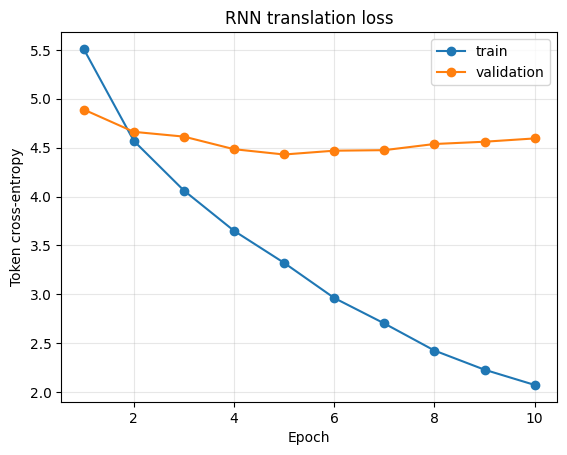

In [5]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

def translation_loss(loader, training):
    model.train(training); total_loss, total_tokens = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits, _ = model(src, tgt, CONFIG["teacher_forcing_ratio"] if training else 0.0)
            gold = tgt[:, 1:]
            loss = criterion(logits.reshape(-1, len(tgt_vocab)), gold.reshape(-1))
            if training:
                loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        tokens = gold.ne(tgt_vocab.pad_idx).sum().item()
        total_loss += loss.item() * tokens; total_tokens += tokens
    return total_loss / total_tokens

history = {"train_loss": [], "val_loss": []}; best_state, best_loss = None, float("inf")
for epoch in range(1, CONFIG["epochs"] + 1):
    started = time.time(); train_loss = translation_loss(train_loader, True); val_loss = translation_loss(val_loader, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    if val_loss < best_loss:
        best_loss = val_loss; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | validation {val_loss:.4f} | {time.time()-started:.1f}s")
model.load_state_dict(best_state)

plt.plot(range(1, CONFIG["epochs"]+1), history["train_loss"], marker="o", label="train")
plt.plot(range(1, CONFIG["epochs"]+1), history["val_loss"], marker="o", label="validation")
plt.xlabel("Epoch"); plt.ylabel("Token cross-entropy"); plt.title("RNN translation loss"); plt.grid(alpha=.3); plt.legend(); plt.show()

## 13–15. Greedy translation, BLEU, examples, and attention visualization

In [6]:
@torch.no_grad()
def translate(sentence):
    model.eval()
    src_tokens = src_vocab.encode(sentence, CONFIG["max_sequence_length"])
    src = torch.tensor(src_tokens, device=DEVICE).unsqueeze(0)
    encoder_outputs, hidden = model.encoder(src); src_mask = src.ne(src_vocab.pad_idx)
    token = torch.tensor([tgt_vocab.bos_idx], device=DEVICE)
    generated, attention_rows = [], []
    for _ in range(CONFIG["max_sequence_length"] - 1):
        logits, hidden, weights = model.decoder(token, hidden, encoder_outputs, src_mask)
        token = logits.argmax(1); next_id = token.item()
        attention_rows.append(weights.squeeze(0).cpu().numpy())
        if next_id == tgt_vocab.eos_idx: break
        generated.append(next_id)
    return tgt_vocab.decode(generated), np.array(attention_rows), [src_vocab.itos[i] for i in src_tokens]

smooth = SmoothingFunction().method1
references, hypotheses, rows = [], [], []
for source, target in test_pairs:
    prediction, _, _ = translate(source)
    ref, hyp = tokenize(target), tokenize(prediction)
    references.append([ref]); hypotheses.append(hyp)
    if len(rows) < 8: rows.append((source, target, prediction))
bleu = corpus_bleu(references, hypotheses, smoothing_function=smooth)
print(f"Corpus BLEU on {len(test_pairs)} test pairs: {bleu:.4f}")
display(pd.DataFrame(rows, columns=["English source", "Actual French", "Predicted French"]))

Corpus BLEU on 500 test pairs: 0.0306


,English source,Actual French,Predicted French
0,How could he claim it without causing suspicio...,Comment aurait-il pu revendiquer l’héritage sa...,comment <unk> <unk> <unk> <unk> <unk> <unk> <u...
1,The yellow curtains along the windows let a he...,"Les rideaux jaunes, le long des fenêtres laiss...","les <unk> <unk> <unk> la <unk> , <unk> <unk> ,..."
2,"Pencroft had torn up his shirt, and was mechan...","Pencroff avait déchiré sa chemise, et, machina...","pencroff , ses <unk> , et <unk> , et fut <unk>..."
3,And that he should have such a strapping son a...,"Et qu'il a, pour continuer la race des Avon, u...",et il ne pouvait un <unk> <unk> <unk> <unk> <u...
4,"'Go,' said Madame de Renal.","– Allez, dit Mme de Rênal.","ah , dit mme de rênal de rênal ."
5,And argued each case with my wife;,Tous les jours avec votre mère ;,"et <unk> , mon mes mon ; ; mon ; mon ami ."
6,They both remained stupefied.,Toutes deux resterent béantes.,on <unk> <unk> <unk> <unk> <unk> <unk> <unk> <...
7,His ordinary occupations were neglected or for...,"Ses occupations habituelles étaient négligées,...",ses <unk> <unk> <unk> <unk> <unk> <unk> <unk> ...


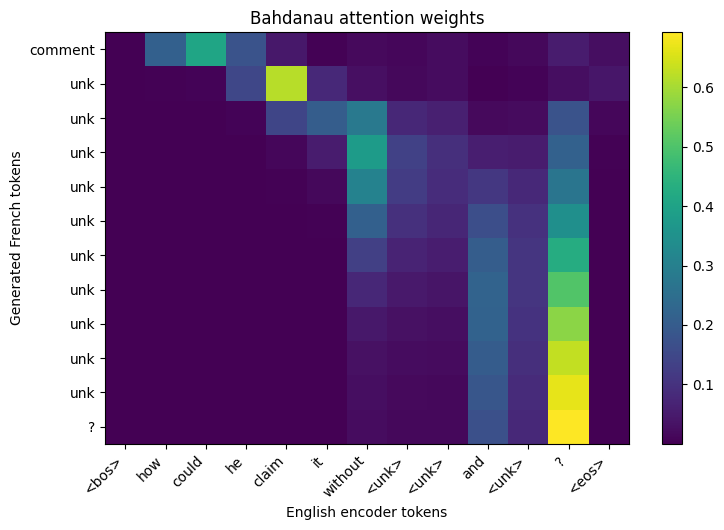

Source: How could he claim it without causing suspicion and inquiry?"
Actual: Comment aurait-il pu revendiquer l’héritage sans provoquer des soupçons et une enquête ?
Predicted: comment <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> ?


In [7]:
source, target = test_pairs[0]
prediction, weights, source_tokens = translate(source)
target_tokens = tokenize(prediction)[:weights.shape[0]]
fig, ax = plt.subplots(figsize=(max(7, len(source_tokens)*.6), max(3, len(target_tokens)*.45)))
image = ax.imshow(weights[:len(target_tokens)], aspect="auto", cmap="viridis")
ax.set_xticks(range(len(source_tokens)), source_tokens, rotation=45, ha="right")
ax.set_yticks(range(len(target_tokens)), target_tokens)
ax.set(xlabel="English encoder tokens", ylabel="Generated French tokens", title="Bahdanau attention weights")
fig.colorbar(image, ax=ax); plt.tight_layout(); plt.show()
print("Source:", source); print("Actual:", target); print("Predicted:", prediction)

## 16–17. Results and conclusion

The reported validation loss, corpus BLEU, examples, and heatmap come from this run. The explicit alignment distribution shows which encoder positions contribute to each generated word. Because this is a small word-level subset with greedy decoding, rare words become `<unk>` and BLEU is expected to trail large subword-based systems. More data, subword tokenization, bidirectional encoding, and beam search are sensible extensions.